<a href="https://colab.research.google.com/github/DeemonDuck/IPO-Signal-Engine/blob/main/EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA) for IPO Project

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("../data/processed/ipo_feature_engineered.csv")

In [ ]:
df.shape
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 561 entries, 0 to 560
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Issue_Size(crores)  561 non-null    float64
 1   QIB                 559 non-null    float64
 2   HNI                 559 non-null    float64
 3   RII                 559 non-null    float64
 4   Total               559 non-null    float64
 5   Offer Price         561 non-null    int64  
 6   Month               561 non-null    int64  
 7   Year                561 non-null    int64  
 8   Demand_Gap          559 non-null    float64
 9   log_issue_size      561 non-null    float64
 10  Apply_Label         561 non-null    int64  
 11  Nifty_Return_7d     561 non-null    float64
dtypes: float64(8), int64(4)
memory usage: 52.7 KB


,Issue_Size(crores),QIB,HNI,RII,Total,Offer Price,Month,Year,Demand_Gap,log_issue_size,Apply_Label,Nifty_Return_7d
count,561.000000,559.000000,559.000000,559.000000,559.000000,561.000000,561.000000,561.000000,559.000000,561.000000,561.000000,561.000000
mean,1411.483957,47.477013,74.686834,15.972165,37.568891,362.187166,7.233512,2018.602496,31.504848,6.362020,0.440285,0.068443
std,2642.439572,63.325282,136.785773,33.155961,53.804193,325.282590,3.456467,5.177968,57.202488,1.337250,0.496864,2.497326
min,23.000000,0.000000,0.000000,0.000000,0.110000,10.000000,1.000000,2010.000000,-331.970000,3.135494,0.000000,-18.252596
25%,251.190000,2.350000,1.710000,1.600000,2.245000,126.000000,4.000000,2015.000000,0.355000,5.526210,0.000000,-1.456290
50%,592.000000,13.720000,13.200000,5.120000,11.520000,258.000000,8.000000,2021.000000,6.490000,6.383507,0.000000,0.285846
75%,1237.510000,76.255000,81.110000,13.750000,55.070000,493.000000,10.000000,2023.000000,49.235000,7.120857,1.000000,1.667673
max,27858.800000,331.600000,958.070000,374.810000,326.490000,2150.000000,12.000000,2025.000000,266.610000,10.234904,1.000000,8.539749


## Checking Class Imbalance

<Axes: xlabel='Apply_Label', ylabel='count'>

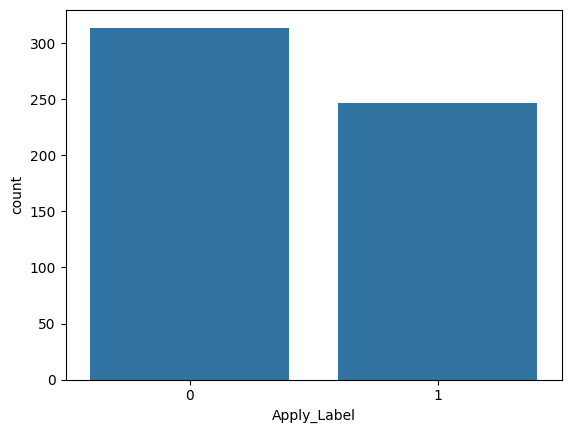

In [ ]:
import seaborn as sns
df["Apply_Label"].value_counts()

sns.countplot(x="Apply_Label", data=df)

In [ ]:
df = df.dropna()

In [ ]:
(df["QIB"] + df["HNI"] + df["RII"] - df["Total"]).abs().describe()

,0
count,559.000000
mean,100.580036
std,150.237869
min,0.470000
25%,4.880000
50%,26.760000
75%,147.095000
max,905.900000


# Observation:
 We will need to drop Total as a Feature from the Datset as it is causing colinearility which will destabalize some Machine Learning Models if not fixed. Feature will be dropped in the end of the EDA.

# Feature Distribution




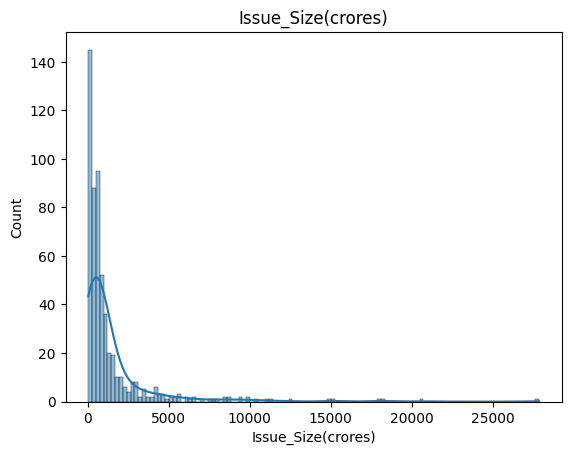

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    "Issue_Size(crores)",
]

for col in features:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

# Observation
## Issue Size Distribution
- The Issue_Size(crores) distribution is highly right-skewed. Most IPOs have relatively small issue sizes, while a few IPOs have extremely large issue sizes exceeding ₹10,000 crores.

- This indicates the presence of large outliers in the dataset. Such skewness can negatively affect some machine learning models. To address this, a log transformation (log_issue_size) was created to normalize the distribution.

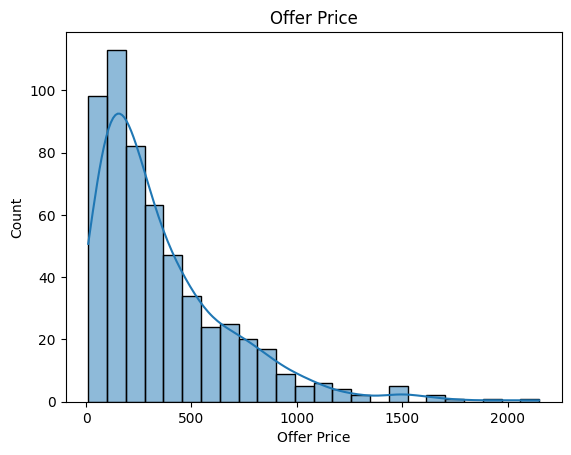

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    "Offer Price",
    ]

for col in features:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

# Observation

- The Offer Price distribution is right-skewed. Most IPOs fall within a lower price range, while only a small number of IPOs have very high offer prices.

- This suggests that the majority of companies issuing IPOs are priced in a relatively moderate range, while premium IPOs are less frequent.

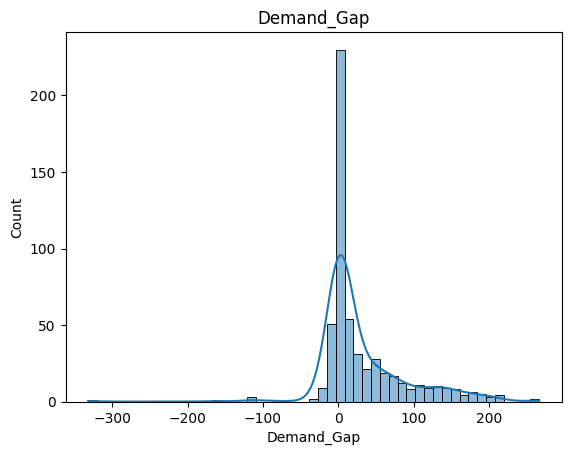

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    "Demand_Gap"
]

for col in features:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

# Observation

- Demand_Gap shows a strong right-skewed distribution. Most IPOs have relatively small demand gaps, but some IPOs experience extremely high demand, leading to very large positive values.

- A few negative values are also present, indicating IPOs where demand was weaker than supply.

- **This feature may be highly informative because strong oversubscription often signals positive investor sentiment.**

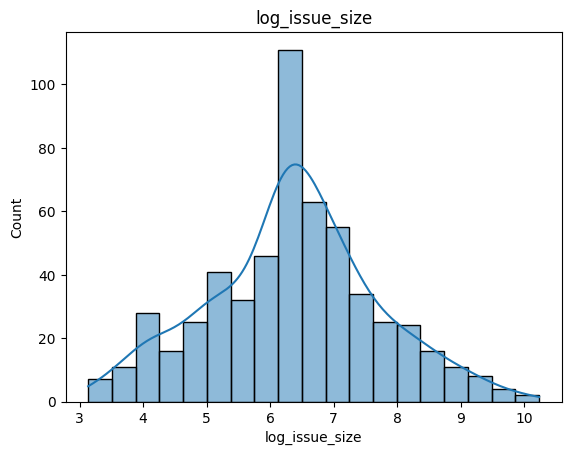

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    "log_issue_size"
]

for col in features:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

# Observation
- The log_issue_size feature appears approximately normally distributed compared to the original issue size.

- This confirms that the logarithmic transformation successfully reduced skewness in the original Issue_Size variable, making it more suitable for machine learning models.

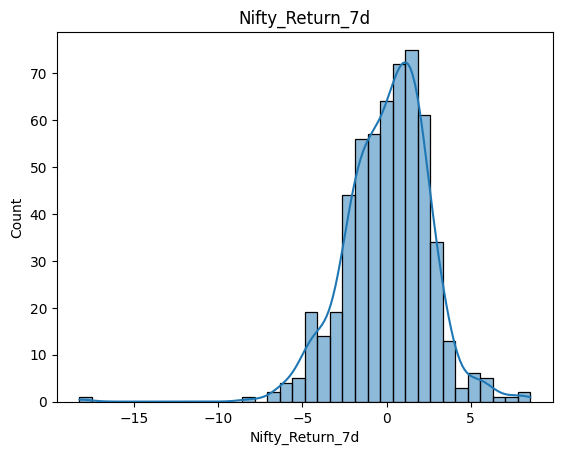

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

features = [
    "Nifty_Return_7d"
]

for col in features:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

# Observation

- The Nifty_Return_7d feature appears roughly normally distributed around zero.

- Most market returns lie between approximately -5% and +5%, indicating typical short-term market fluctuations.

- A few extreme negative and positive returns are also present, which may correspond to major market events or volatility periods.

## Apply vs Not Apply Analysis

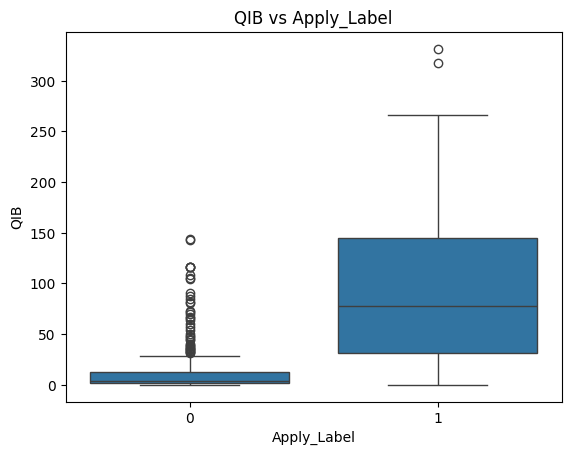

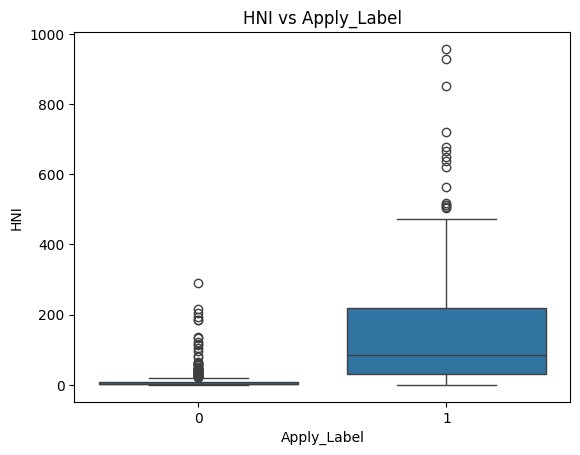

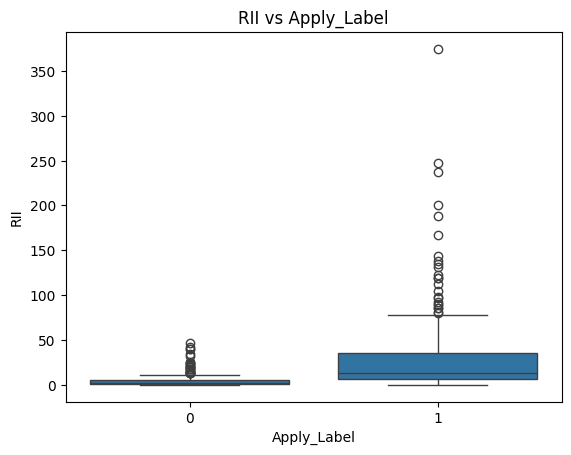

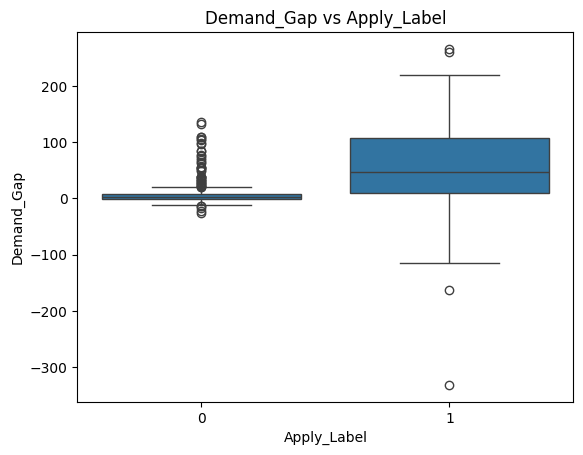

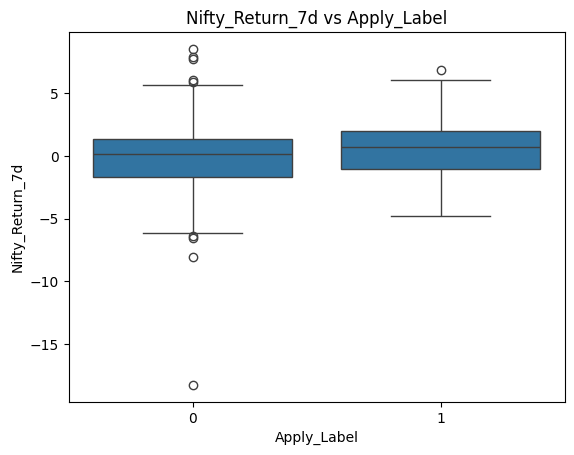

In [ ]:
features = [
    "QIB",
    "HNI",
    "RII",
    "Demand_Gap",
    "Nifty_Return_7d"
]

for col in features:
    plt.figure()
    sns.boxplot(x="Apply_Label", y=col, data=df)
    plt.title(f"{col} vs Apply_Label")
    plt.show()

# Observations:

##  Subscription Demand vs Apply_Label
- The boxplots comparing subscription ratios (QIB, HNI, and RII) with Apply_Label show a clear distinction between successful and unsuccessful IPOs.

- For IPOs labeled as "Apply" (Apply_Label = 1), the median subscription levels for QIB, HNI, and RII investors are significantly higher compared to IPOs labeled as "Not Apply".

- This indicates that higher subscription demand from institutional, high net-worth, and retail investors is strongly associated with better listing performance.

- Additionally, IPOs with low subscription demand tend to fall under the "Not Apply" category, suggesting that investor participation can serve as an important indicator of IPO success.

- **Institutional demand (QIB) appears particularly strong in successful IPOs, suggesting that institutional investor interest may be a key predictive signal.

## Demand Gap vs Apply_Label

- The Demand_Gap feature shows a strong separation between the two classes. IPOs categorized as "Apply" generally have significantly higher demand gaps compared to those labeled "Not Apply".

- This suggests that oversubscription plays an important role in predicting IPO success. IPOs with higher demand relative to supply are more likely to generate strong listing gains.

- Negative demand gap values represent under-subscribed IPOs, which tend to fall into the "Not Apply" category.

## Nifty_Return_7d vs Apply_Label

- The distribution of Nifty_Return_7d shows only a small difference between the two classes. While IPOs categorized as "Apply" tend to have slightly higher median market returns, the overlap between the distributions is substantial.

- This suggests that short-term market sentiment may have a moderate influence on IPO performance, but it is not as strong a predictor as subscription demand variables.

## Correlation Heatmap

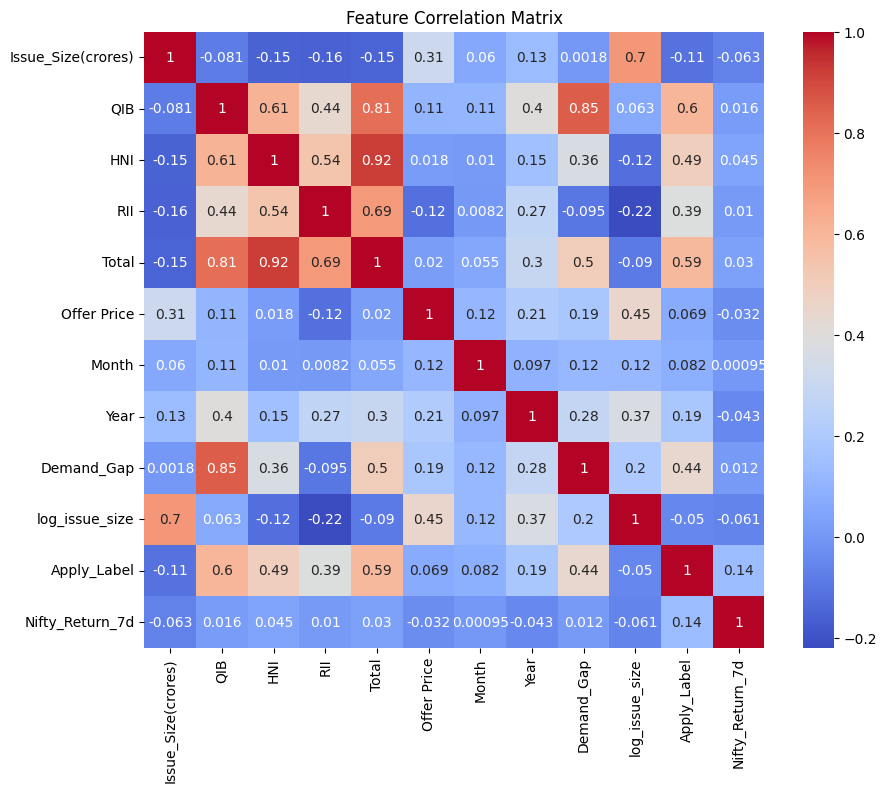

In [ ]:
plt.figure(figsize=(10,8))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Matrix")

plt.show()

# Observation:

The correlation matrix reveals several strong relationships among the features. Subscription-related variables such as QIB, HNI, RII, and Total show strong positive correlations with each other, indicating that IPOs with high demand in one category tend to attract demand across other investor categories as well.

## IPO success by Year

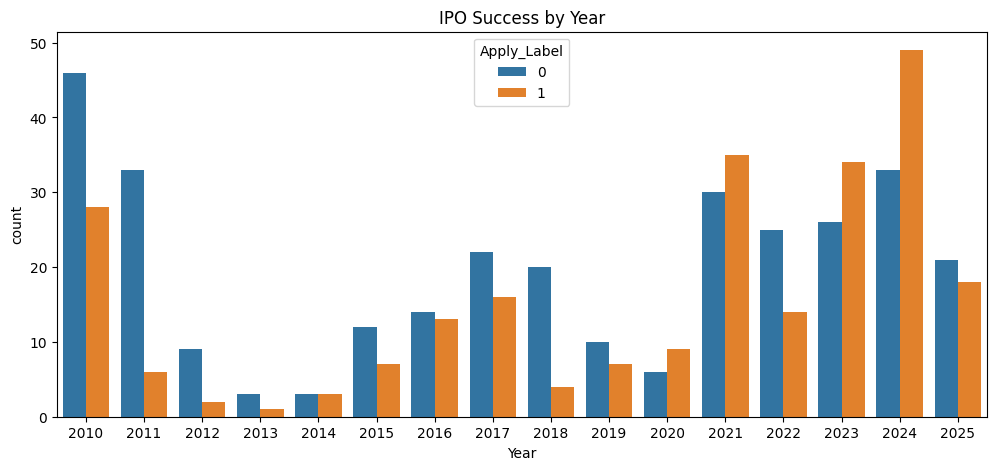

In [ ]:
plt.figure(figsize=(12,5))
sns.countplot(x="Year", hue="Apply_Label", data=df)
plt.title("IPO Success by Year")
plt.show()

# Observation:

- The IPO success rate varies significantly across different years, indicating that IPO performance is influenced by broader market cycles.

- In the early years (2010–2013), the number of IPOs classified as "Not Apply" was higher than successful IPOs, suggesting weaker listing performance during that period.

- From around 2020 onward, the number of successful IPOs (Apply_Label = 1) increases noticeably, especially in 2021 and 2024 where successful IPOs exceed unsuccessful ones.

- This pattern may reflect stronger market conditions and higher investor demand during bullish market periods.

- Overall, the results suggest that macroeconomic and market conditions may influence IPO success, although subscription demand variables appear to be stronger predictors based on earlier analysis.

### **The increase in successful IPOs during 2021–2024 may be linked to the strong post-pandemic bull market in equities.**

In [ ]:
df = df.drop(columns=["Total"])

## Saving Dataset after applying changes

In [ ]:
save_path = "../data/processed/final_ipo_feature_engineered.csv"

In [ ]:
df.to_csv(save_path, index=False)